In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

In [23]:
data_train_path = 'Fruits_Vegetables/train'
data_test_path = 'Fruits_Vegetables/test'
data_val_path = 'Fruits_Vegetables/validation'

In [24]:
img_width = 180
img_height = 180

In [25]:
import tensorflow as tf

data_train = tf.keras.utils.image_dataset_from_directory(
    data_train_path,
    shuffle=True,
    image_size=(img_width, img_height),
    batch_size=32,
    validation_split=False
)

Found 3115 files belonging to 36 classes.


In [26]:
data_cat = data_train.class_names

In [71]:
data_cat

['apple',
 'banana',
 'beetroot',
 'bell pepper',
 'cabbage',
 'capsicum',
 'carrot',
 'cauliflower',
 'chilli pepper',
 'corn',
 'cucumber',
 'eggplant',
 'garlic',
 'ginger',
 'grapes',
 'jalepeno',
 'kiwi',
 'lemon',
 'lettuce',
 'mango',
 'onion',
 'orange',
 'paprika',
 'pear',
 'peas',
 'pineapple',
 'pomegranate',
 'potato',
 'raddish',
 'soy beans',
 'spinach',
 'sweetcorn',
 'sweetpotato',
 'tomato',
 'turnip',
 'watermelon']

In [27]:
data_val_path = "Fruits_Vegetables/validation/"
data_val = tf.keras.utils.image_dataset_from_directory(data_val_path,
                                                       image_size=(img_height,img_width),
                                                       batch_size=32,
                                                       shuffle=False,
                                                       validation_split=False)

Found 351 files belonging to 36 classes.


In [28]:
data_test_path = "Fruits_Vegetables/test/"
data_test = tf.keras.utils.image_dataset_from_directory(
data_test_path,
    image_size=(img_height,img_width),
    shuffle=False,
    batch_size=32,
    validation_split=False
)

Found 359 files belonging to 36 classes.


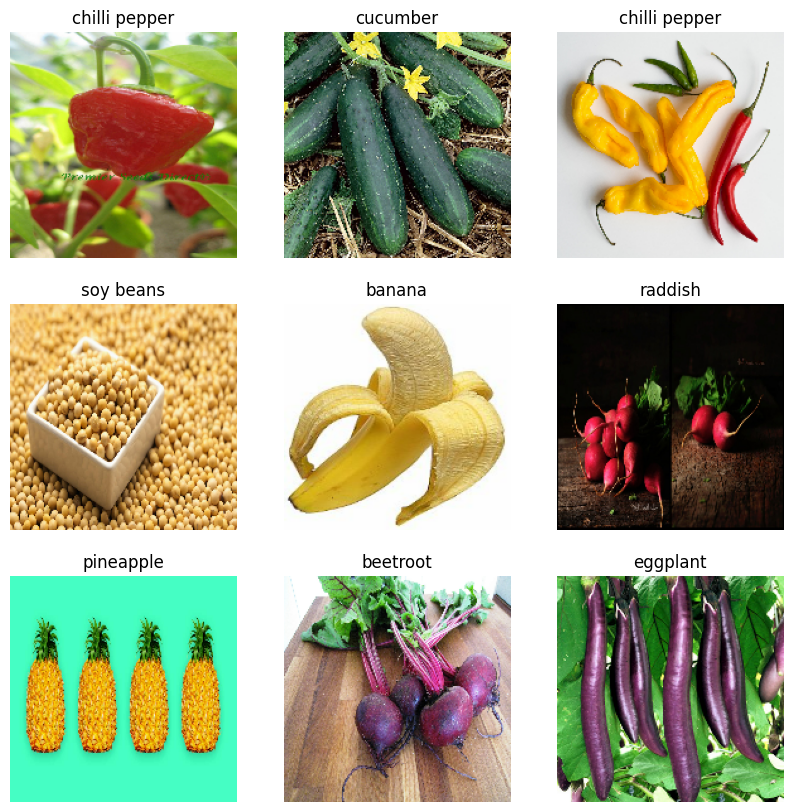

In [30]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
for image, labels in data_train.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(image[i].numpy().astype('uint8'))
        plt.title(data_cat[labels[i]])
        plt.axis('off')

In [20]:
from tensorflow.keras.models import Sequential

In [40]:
model = Sequential([
    layers.Rescaling(1./255),
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32,3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dropout(0.2),
    layers.Dense(128),
    layers.Dense(len(data_cat))
    
])

In [41]:
model.compile(optimizer='adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])

In [42]:
epochs_size = 25
history = model.fit(data_train, validation_data=data_val, epochs=epochs_size)

Epoch 1/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 37s 353ms/step - accuracy: 0.1268 - loss: 3.1773 - val_accuracy: 0.4131 - val_loss: 2.1841
Epoch 2/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 30s 301ms/step - accuracy: 0.3127 - loss: 2.3308 - val_accuracy: 0.5926 - val_loss: 1.5532
Epoch 3/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 30s 301ms/step - accuracy: 0.4716 - loss: 1.7842 - val_accuracy: 0.7521 - val_loss: 0.9433
Epoch 4/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 31s 308ms/step - accuracy: 0.6395 - loss: 1.2306 - val_accuracy: 0.8775 - val_loss: 0.4978
Epoch 5/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 30s 296ms/step - accuracy: 0.7785 - loss: 0.7430 - val_accuracy: 0.9259 - val_loss: 0.4423
Epoch 6/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 31s 318ms/step - accuracy: 0.8896 - loss: 0.4082 - val_accuracy: 0.9316 - val_loss: 0.4343
Epoch 7/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 32s 315ms/step - accuracy: 0.9236 - loss: 0.2965 - val_accuracy: 0.9459 - val_loss: 0.3127
Epoch 8/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 31s 306ms/step - accuracy: 0.9457 - loss: 0.2139 - val_accu

Text(0.5, 1.0, 'Loss')

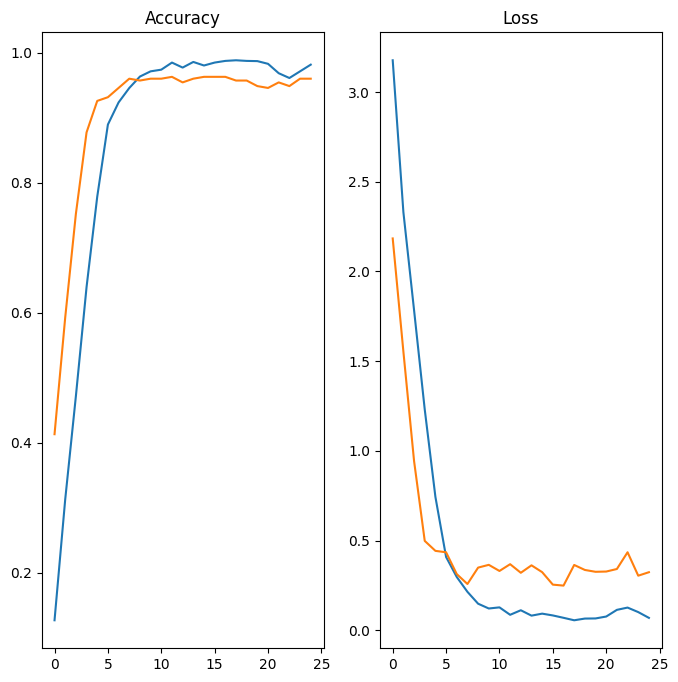

In [56]:
epochs_range = range(epochs_size)
plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(epochs_range,history.history['accuracy'],label = 'Training Accuracy')
plt.plot(epochs_range, history.history['val_accuracy'],label = 'Validation Accuracy')
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs_range,history.history['loss'],label = 'Training Loss')
plt.plot(epochs_range, history.history['val_loss'],label = 'Validation Loss')
plt.title('Loss')

In [66]:
image = 'Corn.jpg'
image = tf.keras.utils.load_img(image, target_size=(img_height,img_width))
img_arr = tf.keras.utils.array_to_img(image)
img_bat=tf.expand_dims(img_arr,0)

In [67]:
predict = model.predict(img_bat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


In [68]:
score = tf.nn.softmax(predict)

In [69]:
print('Veg/Fruit in image is {} with accuracy of {:0.2f}'.format(data_cat[np.argmax(score)],np.max(score)*100))

Veg/Fruit in image is sweetcorn with accuracy of 54.75


In [70]:
model.save('Image_classify.keras')